# **Linear Regression**
## **House Price Prediction**

## 1. Import Libraries

In [ ]:
!pip install kagglehub

In [2]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # scikit-learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

## 2. Download Dataset

In [3]:
# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 3.44MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


## 3. Exploratory Data Analysis

In [5]:
dataset = pd.read_csv(f'{path}/Housing.csv')

In [6]:
dataset.head() # Samples from the dataframe

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
dataset.shape

(545, 13)

In [8]:
categorical_cols = dataset.select_dtypes(include=['object']).columns # dtype - Selecting Data Type
print("Categorical variables:", len(categorical_cols))

Categorical variables: 7


In [9]:
categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [10]:
integer_cols = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(integer_cols))

Integer variables: 6


In [11]:
integer_cols

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [12]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [13]:
dataset.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [14]:
dataset['mainroad'].unique()

array(['yes', 'no'], dtype=object)

In [15]:
dataset['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

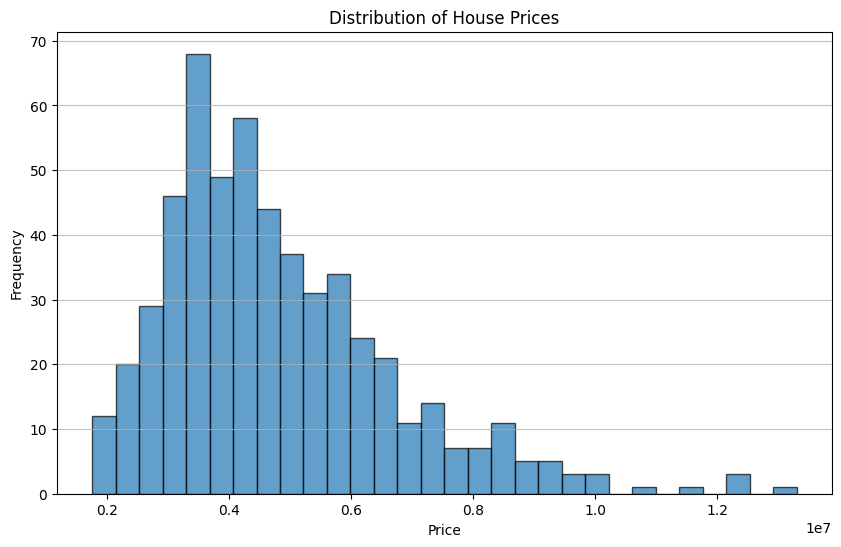

In [16]:
plt.figure(figsize=(10, 6)) # Figure Size
plt.hist(dataset['price'], bins=30, edgecolor='k', alpha=0.7) #
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 4. Reproducibility

In [17]:
np.random.seed(42)

## 5. Data Pre-processing

In [18]:
y = dataset['price'] # Target
X = dataset[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom']] # 12 Features - 6 features (Input)

# Task 1 - Use all 12 Features
# Task 2 - Randomly select 6 - pandas library

X.shape, y.shape

((545, 6), (545,))

In [19]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42) # f(X,y, test_size, rs)

In [20]:
X_train.shape, X_test.shape

((436, 6), (109, 6))

In [21]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
print("Categorical variables:", len(categorical_cols))

integer_cols = X_train.select_dtypes(include=['int64']).columns
print("Integer variables:", len(integer_cols))

Categorical variables: 2
Integer variables: 4


In [22]:
categorical_cols

Index(['mainroad', 'guestroom'], dtype='object')

In [23]:
X_train_cat = X_train[categorical_cols]
X_train_int = X_train[integer_cols]

X_test_cat = X_test[categorical_cols]
X_test_int = X_test[integer_cols]

In [24]:
X_train_cat.head(1)

,mainroad,guestroom
46,yes,no


YES - 1

NO - 2

ONE HOT ENCODING

[1 0 0]

[0 1 0]

[0 0 1]

In [25]:
encoder=OneHotEncoder(sparse_output=False,drop='first') # Category - numbers ONE HOT ENCODING

X_train_encoded=encoder.fit_transform(X_train_cat) # fit_transform (compute) , transform (inference)

X_test_encoded=encoder.transform(X_test_cat)

In [26]:
X_train_encoded[0]

array([1., 0.])

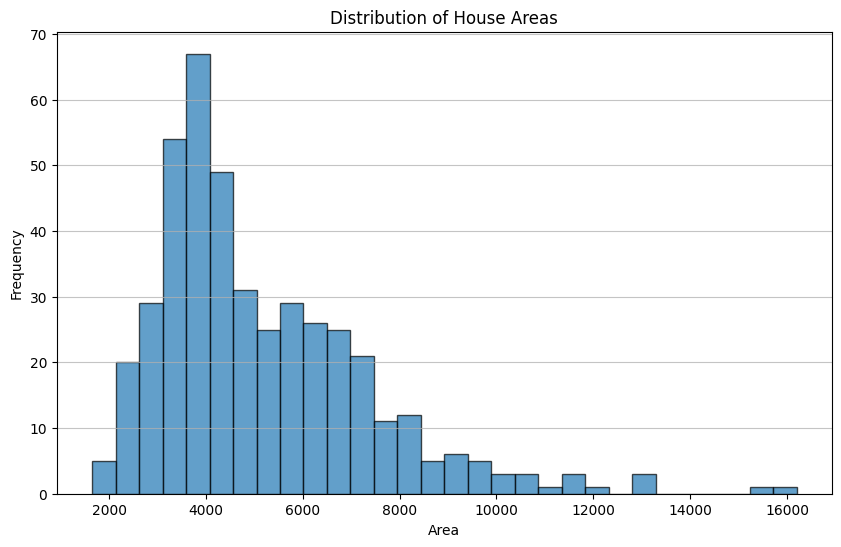

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(X_train_int['area'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Areas')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [28]:
X_train_int['area'].describe()

,area
count,436.000000
mean,5154.144495
std,2204.313664
min,1650.000000
25%,3600.000000
50%,4500.000000
75%,6360.000000
max,16200.000000


In [29]:
standard=StandardScaler() # z= (X-mean)/std mean=0, std=1

X_train_scaled=standard.fit_transform(X_train_int) # Compute - Mean, STD -> 0,1

X_test_scaled=standard.transform(X_test_int)# Mean, STD -> 0,1

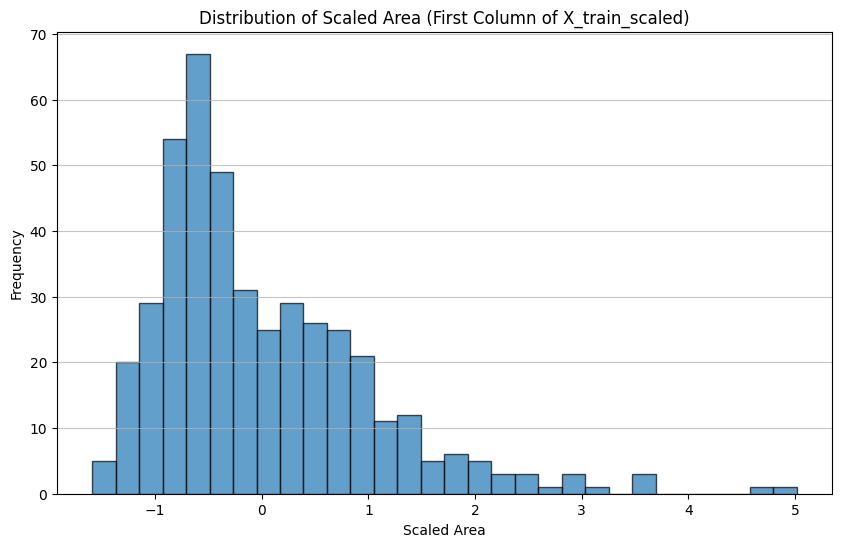

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(X_train_scaled[:, 0], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Scaled Area (First Column of X_train_scaled)')
plt.xlabel('Scaled Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [31]:
X_train_int['area'].head()

,area
46,6000
93,7200
335,3816
412,2610
471,3750


In [32]:
X_train_scaled[:5, 0]

array([ 0.38416819,  0.9291807 , -0.60775457, -1.15549214, -0.63773026])

In [33]:
print("Mean", X_train_scaled[:, 0].mean())
print("Standard Deviation", X_train_scaled[:, 0].std())

Mean 1.2222638803212733e-16
Standard Deviation 1.0000000000000002


In [34]:
X_train_final=np.concatenate((X_train_encoded,X_train_scaled),axis=1)
X_test_final=np.concatenate((X_test_encoded,X_test_scaled),axis=1)

In [35]:
X_train_final.shape, X_test_final.shape

((436, 6), (109, 6))

## 6. Model Development

MSE = 1/N sum(y-yhat)^2

MSE = 1/N sum(y-(Xw+b))^2

w [1x6], b[1]

grad_w = 1/N sum(2*(y-y_hat)(0-X+0)) = -2/N sum((y-yhat) X) -> 1xN Nx6 -> 1x6

grad_b = 1/N 2*sum(y-yhat) (0-0+1) = -2/N sum(y-yhat) -> 1

w_new = w_old - lr*grad_w

b_new = w_old - lr*grad_b

a = [1 2 3]^2 = a^T a

[1
2
3]  [1 2 3] = [1 4 9]

In [36]:
class LinearRegression():

    def __init__(self, X, y, learning_rate, epoch):
        # Number of Samples
        self.samples = X.size
        self.X = X
        self.y = y
        self.alpha = learning_rate
        self.epoch = epoch
        # Initiate gradients and weights to zero
        self.b = 0 # np.random()
        self.w = np.zeros(X.shape[1])
        self.grad_b = 0
        self.grad_w = np.zeros(X.shape[1])
        self.loss_history = []

    # Mean Square Error loss function
    def compute_loss(self):
        error = self.y - self.y_hat # N
        loss = 1/(self.samples) * np.dot(error.T, error) # 1/N sum(y-yhat)^2
        return loss

    # Compute gradients
    def compute_gradient(self):
        self.grad_b = -(2/self.samples) * sum(self.y - self.y_hat)
        self.grad_w = -(2/self.samples) * sum(np.dot(self.X.T , (self.y - self.y_hat)))

    # Forward Pass (compute yhat)
    # Calculate loss
    # Compute Gradient
    # Update Weights
    # Validation loop
    # Decision

    # Compute Weight using the Gradient descent
    def train(self, show_training_updates = False):
        self.loss_history=[]
        for i in range(self.epoch):
            # Predict and Calculate Loss
                self.y_hat = np.dot(self.X,self.w) + self.b
                loss = self.compute_loss()
                self.loss_history.append(loss)
            # Perform optimization
                # Compute gradient
                self.compute_gradient()
                # Update weights
                self.b = self.b - (self.alpha * self.grad_b)
                self.w = self.w - (self.alpha * self.grad_w)
                print(f"Training Loss: {loss}, w={self.w}, b={self.b}")
            # Plot Training updates
                if show_training_updates:
                    plt.figure(figsize=(8, 4),  dpi=80)
                    plt.title('Training Update Epoch: {}'.format(str(i+1)))
                    plt.scatter(self.y, self.y_hat, alpha=0.7)
                    plt.plot([self.y.min(), self.y.max()], [self.y_hat.min(), self.y_hat.max()], 'r--', lw=2)
                    plt.show()
        return self.b, self.w, self.loss_history

    # Predict values for new data
    def predict(self, x):
        return np.dot(x, self.w) + self.b

## 7. Training

In [37]:
# Initiate Hyperparameters
learning_rate = 0.00001
epochs = 5000

# Initiate the model
model = LinearRegression(X_train_final, y_train, learning_rate, epochs)

In [38]:
bias, weights, loss_history = model.train(show_training_updates=False)

Streaming output truncated to the last 5000 lines.
Training Loss: 3961406237652.808, w=[67866.65650438 67866.65650438 67866.65650438 67866.65650438
 67866.65650438 67866.65650438], b=38746.57565608678
Training Loss: 3961314743015.0254, w=[67892.73451021 67892.73451021 67892.73451021 67892.73451021
 67892.73451021 67892.73451021], b=38761.9004015323
Training Loss: 3961223253199.4556, w=[67918.81167446 67918.81167446 67918.81167446 67918.81167446
 67918.81167446 67918.81167446], b=38777.22500577868
Training Loss: 3961131768205.808, w=[67944.88799717 67944.88799717 67944.88799717 67944.88799717
 67944.88799717 67944.88799717], b=38792.5494688293
Training Loss: 3961040288033.789, w=[67970.96347836 67970.96347836 67970.96347836 67970.96347836
 67970.96347836 67970.96347836], b=38807.87379068753
Training Loss: 3960948812683.1094, w=[67997.03811806 67997.03811806 67997.03811806 67997.03811806
 67997.03811806 67997.03811806], b=38823.19797135676
Training Loss: 3960857342153.4785, w=[68023.1119

In [39]:
weights

array([130523.05830941, 130523.05830941, 130523.05830941, 130523.05830941,
       130523.05830941, 130523.05830941])

In [40]:
bias

76640.97766625683

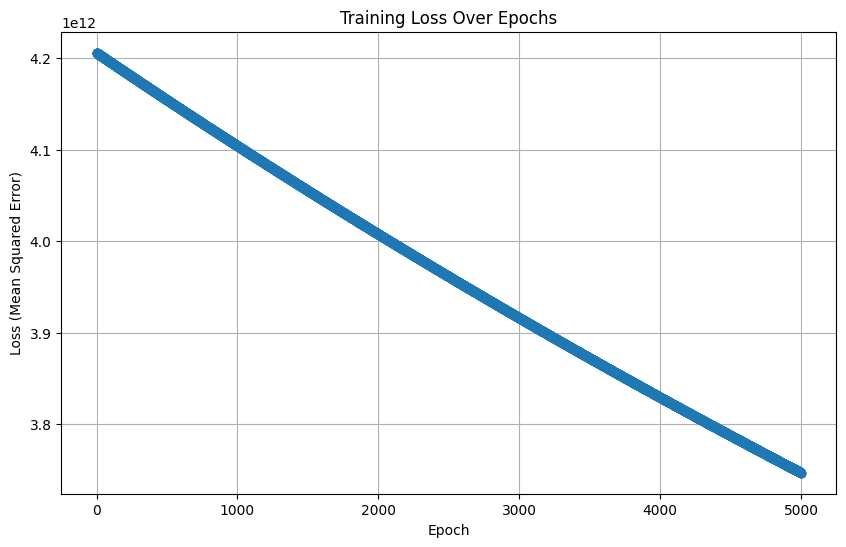

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, marker='o', linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.grid(True)
plt.show()

## 8. Model Testing

In [42]:
y_pred = model.predict(X_test_final)

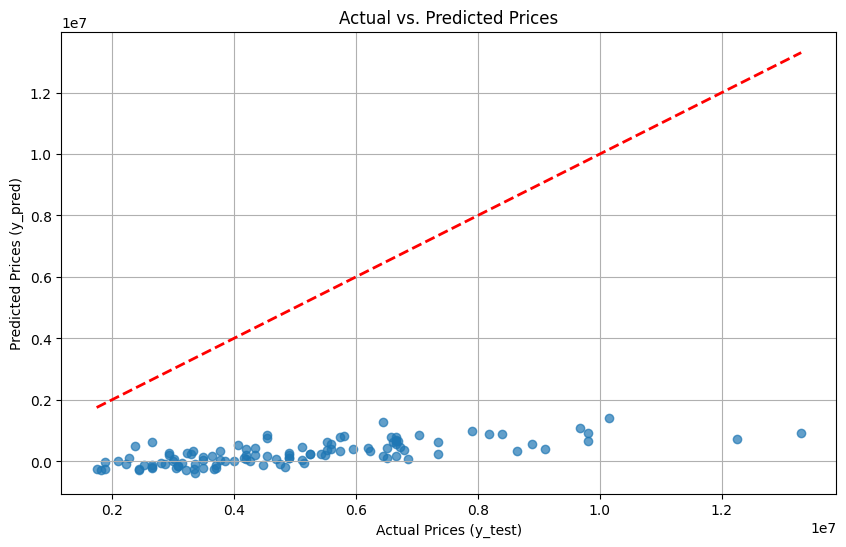

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (y_test)')
plt.ylabel('Predicted Prices (y_pred)')
plt.grid(True)
plt.show()

In [44]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: -4.238176653671303
